# 02 — MLP Multi-class Classifier

**Strategy.** No GAN. No undersampling. We let the *loss function* — not the
data distribution — handle the class imbalance:

1. **Class weights** (default) — `sklearn`-balanced weights, passed to
   `model.fit(class_weight=...)`. Errors on rare classes get scaled up
   proportionally.
2. **Focal loss** (alternative) — flip `cfg.MLP_CONFIG["imbalance_strategy"]`
   to `"focal"` to use focal loss instead.

We track **macro-F1** (not accuracy) because accuracy is dominated by BENIGN.

---

## Table of Contents

1. [Load data, scaler, label map](#1.-Load-data,-scaler,-label-map)
2. [Class distribution (kept untouched)](#2.-Class-distribution-(kept-untouched))
3. [Compute class weights](#3.-Compute-class-weights)
4. [Build the MLP (baseline architecture)](#4.-Build-the-MLP)
5. [Train baseline MLP](#5.-Train-baseline-MLP)
6. [Hyperparameter tuning (RandomizedSearchCV)](#6.-Hyperparameter-tuning)
7. [Retrain MLP with best hyperparameters](#7.-Retrain-MLP-with-best-hyperparameters)
8. [Learning curves](#8.-Learning-curves)
9. [Validation report (per-class & macro)](#9.-Validation-report)
10. [Confusion matrix](#10.-Confusion-matrix)
11. [Persist the best model and tuning history](#11.-Persist-the-best-model)

---


In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
)
from sklearn.utils.class_weight import compute_class_weight

from src import config as cfg
sns.set_theme(style="whitegrid")
print("TF:", tf.__version__)
print("Imbalance strategy:", cfg.MLP_CONFIG["imbalance_strategy"])


TF: 2.21.0
Imbalance strategy: class_weights


## 1. Load data, scaler, label map

In [2]:
train = pd.read_csv(cfg.PROCESSED_DIR / "train.csv")
val   = pd.read_csv(cfg.PROCESSED_DIR / "val.csv")

scaler = joblib.load(cfg.SCALER_FILE)
with open(cfg.FEATURE_NAMES_FILE) as f: feature_names = json.load(f)
with open(cfg.LABEL_MAP_FILE)    as f: label_map = {int(k):v for k,v in json.load(f).items()}
inv_map = {v:k for k,v in label_map.items()}
class_names = [label_map[i] for i in range(len(label_map))]

# Some rows in val may carry rare labels we dropped at preprocessing.
train = train[train[cfg.LABEL_COL].isin(inv_map)].reset_index(drop=True)
val   = val[val[cfg.LABEL_COL].isin(inv_map)].reset_index(drop=True)

X_train = scaler.transform(train[feature_names].astype(np.float32).values)
y_train = train[cfg.LABEL_COL].map(inv_map).astype(int).values
X_val   = scaler.transform(val[feature_names].astype(np.float32).values)
y_val   = val[cfg.LABEL_COL].map(inv_map).astype(int).values

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  classes: {len(label_map)}")


X_train: (1979465, 77)  X_val: (424171, 77)  classes: 12


## 2. Class distribution (kept untouched)

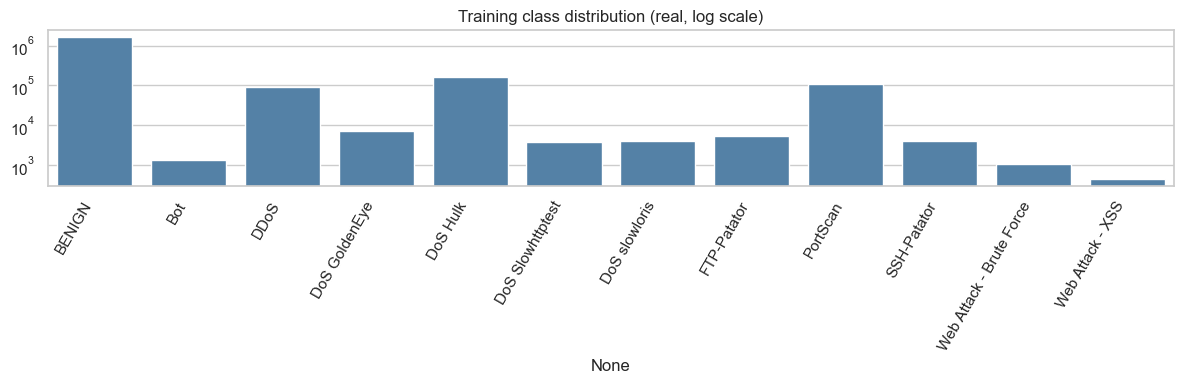

BENIGN                      1589924
Bot                            1369
DDoS                          89617
DoS GoldenEye                  7205
DoS Hulk                     161087
DoS Slowhttptest               3849
DoS slowloris                  4057
FTP-Patator                    5555
PortScan                     111163
SSH-Patator                    4128
Web Attack - Brute Force       1055
Web Attack - XSS                456
Name: count, dtype: int64


In [3]:
dist = pd.Series(y_train).value_counts().sort_index()
dist.index = [class_names[i] for i in dist.index]
plt.figure(figsize=(12, 4))
sns.barplot(x=dist.index, y=dist.values, color="steelblue")
plt.yscale("log")
plt.xticks(rotation=60, ha="right")
plt.title("Training class distribution (real, log scale)")
plt.tight_layout(); plt.show()
print(dist)


## 3. Compute class weights

`compute_class_weight('balanced', ...)` gives weight ∝ N / (n_classes * count_class).
We cap at `cfg.MLP_CONFIG['max_class_weight']` so the rarest classes don't
explode the gradient.


In [4]:
def compute_balanced_class_weights(y, max_weight=50.0):
    """sklearn-balanced class weights, capped at `max_weight`."""
    classes = np.unique(y)
    raw = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    capped = np.minimum(raw, max_weight)
    return {int(c): float(w) for c, w in zip(classes, capped)}


class_weights = compute_balanced_class_weights(
    y_train, max_weight=cfg.MLP_CONFIG["max_class_weight"]
)

cw_df = pd.DataFrame([
    {"class": class_names[i], "count": int((y_train == i).sum()), "weight": class_weights[i]}
    for i in sorted(class_weights)
]).sort_values("weight", ascending=False)
print(cw_df.to_string(index=False))


                   class   count    weight
                     Bot    1369 10.000000
           DoS GoldenEye    7205 10.000000
           DoS slowloris    4057 10.000000
        DoS Slowhttptest    3849 10.000000
        Web Attack - XSS     456 10.000000
Web Attack - Brute Force    1055 10.000000
             FTP-Patator    5555 10.000000
             SSH-Patator    4128 10.000000
                    DDoS   89617  1.840671
                PortScan  111163  1.483906
                DoS Hulk  161087  1.024014
                  BENIGN 1589924  0.103751


## 4. Build the MLP (baseline architecture)

Architecture: `[512 → 256 → 128]` Dense + BatchNorm + Dropout, softmax head.
This is the *baseline* configuration straight from `cfg.MLP_CONFIG` — we'll
retrain after hyperparameter tuning in section 7.


In [5]:
def sparse_categorical_focal_loss(gamma: float = 2.0, alpha: float = 0.25):
    """Focal loss for sparse integer labels.

    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)

    `gamma` down-weights easy examples (high p_t); `alpha` is a global
    rebalancing scalar. Use when class imbalance is severe but you do not
    want to pass `class_weight` at fit time.
    """
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        idx = tf.stack(
            [tf.range(tf.shape(y_true)[0]), tf.reshape(y_true, [-1])], axis=1
        )
        p_t = tf.gather_nd(y_pred, idx)
        focal = -alpha * tf.pow(1.0 - p_t, gamma) * tf.math.log(p_t)
        return tf.reduce_mean(focal)
    loss.__name__ = "sparse_categorical_focal_loss"
    return loss


def build_mlp(input_dim, n_classes, hidden_units=(256, 128, 64),
              dropout=0.3, learning_rate=1e-3,
              loss="sparse_categorical_crossentropy",
              focal_gamma=2.0, focal_alpha=0.25):
    """Plain MLP classifier with BatchNorm + Dropout regularisation."""
    inputs = layers.Input(shape=(input_dim,), name="features")
    x = inputs
    for i, units in enumerate(hidden_units):
        x = layers.Dense(units, activation="relu", name=f"dense_{i}")(x)
        x = layers.BatchNormalization(name=f"bn_{i}")(x)
        x = layers.Dropout(dropout, name=f"drop_{i}")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="probs")(x)

    loss_fn = sparse_categorical_focal_loss(focal_gamma, focal_alpha) \
        if loss == "focal" else "sparse_categorical_crossentropy"

    m = models.Model(inputs, outputs, name="smarttids_mlp")
    m.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
              loss=loss_fn, metrics=["accuracy"])
    return m


strategy = cfg.MLP_CONFIG["imbalance_strategy"]
loss_kind = "focal" if strategy == "focal" else "sparse_categorical_crossentropy"

model = build_mlp(
    input_dim=X_train.shape[1],
    n_classes=len(label_map),
    hidden_units=cfg.MLP_CONFIG["hidden_units"],
    dropout=cfg.MLP_CONFIG["dropout"],
    learning_rate=cfg.MLP_CONFIG["learning_rate"],
    loss=loss_kind,
    focal_gamma=cfg.MLP_CONFIG["focal_gamma"],
    focal_alpha=cfg.MLP_CONFIG["focal_alpha"],
)
model.summary()


2026-05-17 23:44:50,741 [WARNING] tensorflow: TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Model: "smarttids_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 512)            │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_0 (Dropout)                │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,292 (817.55 KB)

 Trainable params: 207,500 (810.55 KB)

 Non-trainable params: 1,792 (7.00 KB)

### Macro-F1 callback

Keras reports loss and accuracy out of the box; on this imbalanced dataset
those are dominated by BENIGN. We add a custom callback that computes
**macro-F1 on the validation set after each epoch**, so the model checkpoint
and early-stopping logic optimise the metric we actually care about.


In [6]:
class MacroF1Callback(tf.keras.callbacks.Callback):
    """Compute macro-F1 on the validation set after each epoch."""
    def __init__(self, X, y):
        super().__init__()
        self.X, self.y = X, y
        self.history = []
    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X, batch_size=4096, verbose=0).argmax(axis=1)
        score = f1_score(self.y, y_pred, average="macro", zero_division=0)
        logs = logs or {}
        logs["val_macro_f1"] = score
        self.history.append(score)
        print(f"  -> val_macro_f1: {score:.4f}")

f1_cb = MacroF1Callback(X_val, y_val)


## 5. Train baseline MLP

Train with the default config, monitoring macro-F1 on validation. We keep
this run's `history` and validation metrics under `baseline_*` so we can
plot **before/after tuning** in notebook 04.


In [7]:
cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)

callbacks = [
    f1_cb,
    EarlyStopping(monitor="val_macro_f1", mode="max",
                  patience=cfg.MLP_CONFIG["patience"], restore_best_weights=True),
    # Monitor macro-F1 (max) instead of val_loss — with class weights the
    # weighted val_loss is a noisy proxy for actual classification quality.
    ReduceLROnPlateau(monitor="val_macro_f1", mode="max",
                      factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint(filepath=str(cfg.MLP_MODEL_FILE),
                    monitor="val_macro_f1", mode="max", save_best_only=True),
]

# class_weight is only used for the cross-entropy strategy.
fit_kwargs = {}
if strategy == "class_weights":
    fit_kwargs["class_weight"] = class_weights
    print("Training with sklearn-balanced class weights.")
elif strategy == "focal":
    print(f"Training with focal loss (gamma={cfg.MLP_CONFIG['focal_gamma']}, "
          f"alpha={cfg.MLP_CONFIG['focal_alpha']}).")
else:
    print("WARNING: imbalance_strategy='none' — model will likely collapse to BENIGN.")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=cfg.MLP_CONFIG["epochs"],
    batch_size=cfg.MLP_CONFIG["batch_size"],
    callbacks=callbacks,
    verbose=2,
    **fit_kwargs,
)


Training with sklearn-balanced class weights.
Epoch 1/60
  -> val_macro_f1: 0.5866
967/967 - 69s - 72ms/step - accuracy: 0.8439 - loss: 0.1278 - val_accuracy: 0.9187 - val_loss: 0.1999 - val_macro_f1: 0.5866 - learning_rate: 0.0010
Epoch 2/60
  -> val_macro_f1: 0.6157
967/967 - 67s - 69ms/step - accuracy: 0.9059 - loss: 0.0621 - val_accuracy: 0.9218 - val_loss: 0.1967 - val_macro_f1: 0.6157 - learning_rate: 0.0010
Epoch 3/60
  -> val_macro_f1: 0.6132
967/967 - 64s - 67ms/step - accuracy: 0.9138 - loss: 0.0534 - val_accuracy: 0.9195 - val_loss: 0.2165 - val_macro_f1: 0.6132 - learning_rate: 0.0010
Epoch 4/60
  -> val_macro_f1: 0.6313
967/967 - 65s - 67ms/step - accuracy: 0.9180 - loss: 0.0495 - val_accuracy: 0.9166 - val_loss: 0.1998 - val_macro_f1: 0.6313 - learning_rate: 0.0010
Epoch 5/60
  -> val_macro_f1: 0.6392
967/967 - 70s - 72ms/step - accuracy: 0.9204 - loss: 0.0467 - val_accuracy: 0.9198 - val_loss: 0.1944 - val_macro_f1: 0.6392 - learning_rate: 0.0010
Epoch 6/60
  -> val_macr

In [8]:
# Snapshot baseline metrics so we can plot before/after tuning in NB 04.
baseline_history     = {k: list(map(float, v)) for k, v in history.history.items()}
baseline_f1_history  = list(map(float, f1_cb.history))

y_pred_baseline = model.predict(X_val, batch_size=4096, verbose=0).argmax(axis=1)
all_labels = list(range(len(class_names)))
baseline_val_metrics = {
    "macro_f1":    float(f1_score(y_val, y_pred_baseline, labels=all_labels,
                                  average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(y_val, y_pred_baseline, labels=all_labels,
                                  average="weighted", zero_division=0)),
}
print("Baseline MLP — validation:")
for k, v in baseline_val_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

# Persist baseline history to disk for NB 04 plotting.
cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open(cfg.MODELS_DIR / "mlp_baseline_history.json", "w") as f:
    json.dump({"history": baseline_history,
               "f1_history": baseline_f1_history,
               "val_metrics": baseline_val_metrics}, f, indent=2)
print(f"\nBaseline history saved -> {cfg.MODELS_DIR / 'mlp_baseline_history.json'}")


Baseline MLP — validation:
  macro_f1    : 0.7376
  weighted_f1 : 0.9839

Baseline history saved -> D:\smart_ids\smart_ids\models\mlp_baseline_history.json


## 6. Hyperparameter tuning (Randomized search with cross-validation)

A full grid search on a 2M-row Keras model is impractical, so we run a
**stratified randomized search with 3-fold cross-validation** on a 150k
subsample. The search space covers:

| Hyperparameter   | Candidates                                  |
|------------------|---------------------------------------------|
| `hidden_units`   | `[256,128]`, `[512,256]`, `[512,256,128]`, `[256,128,64]` |
| `dropout`        | `0.2`, `0.3`, `0.4`                         |
| `learning_rate`  | `1e-3`, `5e-4`, `2e-4`                      |
| `batch_size`     | `1024`, `2048`                              |

`N_TRIALS` configurations are sampled and each is evaluated by mean macro-F1
across the 3 CV folds. We pick the best-scoring config and retrain on the
full training set in section 7.

> Conceptually equivalent to `RandomizedSearchCV` — we implement it manually
> because TensorFlow models + class-weights don't play nicely with sklearn's
> wrapper, especially on Windows.


In [9]:
import itertools
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

# --- search space -------------------------------------------------------
param_grid = {
    "hidden_units": [[256, 128], [512, 256], [512, 256, 128], [256, 128, 64]],
    "dropout":       [0.2, 0.3, 0.4],
    "learning_rate": [1e-3, 5e-4, 2e-4],
    "batch_size":    [1024, 2048],
}
all_configs = [dict(zip(param_grid, vals))
               for vals in itertools.product(*param_grid.values())]
print(f"Full grid size       : {len(all_configs)} configurations")

# Randomize and trim to N_TRIALS — keep wall-clock tractable.
N_TRIALS = 8
N_FOLDS  = 3
TUNE_SAMPLE = 150_000
TUNE_EPOCHS = 12  # short training; macro-F1 stabilises within ~10 epochs

rng = np.random.RandomState(cfg.RANDOM_STATE)
rng.shuffle(all_configs)
configs_to_try = all_configs[:N_TRIALS]
print(f"Sampled configurations: {len(configs_to_try)} (N_TRIALS={N_TRIALS})")

# --- stratified subsample for tuning -----------------------------------
sss = StratifiedShuffleSplit(n_splits=1, train_size=TUNE_SAMPLE,
                             random_state=cfg.RANDOM_STATE)
idx, _ = next(sss.split(X_train, y_train))
X_tune, y_tune = X_train[idx], y_train[idx]
print(f"Tuning subsample      : {X_tune.shape}")


Full grid size       : 72 configurations
Sampled configurations: 8 (N_TRIALS=8)
Tuning subsample      : (150000, 77)


In [10]:
def evaluate_config(params: dict, X, y, n_folds: int = N_FOLDS,
                    epochs: int = TUNE_EPOCHS) -> dict:
    """Train+score a single config across `n_folds` stratified folds.
    Returns mean and std macro-F1 across folds."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True,
                          random_state=cfg.RANDOM_STATE)
    fold_scores = []
    for fold, (tr, va) in enumerate(skf.split(X, y)):
        cw = compute_balanced_class_weights(y[tr], max_weight=10.0)
        m = build_mlp(
            input_dim=X.shape[1],
            n_classes=len(label_map),
            hidden_units=params["hidden_units"],
            dropout=params["dropout"],
            learning_rate=params["learning_rate"],
        )
        m.fit(X[tr], y[tr],
              validation_data=(X[va], y[va]),
              epochs=epochs,
              batch_size=params["batch_size"],
              class_weight=cw,
              verbose=0)
        y_pred = m.predict(X[va], batch_size=4096, verbose=0).argmax(axis=1)
        fold_scores.append(f1_score(y[va], y_pred, average="macro",
                                    zero_division=0))
        tf.keras.backend.clear_session()
    return {"mean_macro_f1": float(np.mean(fold_scores)),
            "std_macro_f1":  float(np.std(fold_scores)),
            "fold_scores":   list(map(float, fold_scores))}

# Run the search.
results = []
for i, params in enumerate(configs_to_try, 1):
    print(f"\n[{i}/{len(configs_to_try)}] params = {params}")
    score = evaluate_config(params, X_tune, y_tune)
    print(f"  -> mean macro-F1: {score['mean_macro_f1']:.4f} "
          f"(+/- {score['std_macro_f1']:.4f})")
    results.append({**params, **score})

tuning_df = (pd.DataFrame(results)
               .sort_values("mean_macro_f1", ascending=False)
               .reset_index(drop=True))
print("\n=== Hyperparameter search results ===")
print(tuning_df[["hidden_units", "dropout", "learning_rate", "batch_size",
                 "mean_macro_f1", "std_macro_f1"]].to_string(index=False))

best_params = tuning_df.iloc[0][["hidden_units", "dropout",
                                  "learning_rate", "batch_size"]].to_dict()
print(f"\nBest params: {best_params}")
print(f"Best mean macro-F1 (CV): {tuning_df.iloc[0]['mean_macro_f1']:.4f}")

# Persist the tuning history for NB 04.
tuning_df.to_csv(cfg.MODELS_DIR / "mlp_tuning_results.csv", index=False)
with open(cfg.MODELS_DIR / "mlp_best_params.json", "w") as f:
    json.dump({k: (list(v) if isinstance(v, (list, tuple, np.ndarray)) else v)
               for k, v in best_params.items()}, f, indent=2)
print(f"Saved tuning results -> {cfg.MODELS_DIR / 'mlp_tuning_results.csv'}")



[1/8] params = {'hidden_units': [256, 128], 'dropout': 0.2, 'learning_rate': 0.0002, 'batch_size': 1024}



2026-05-18 00:53:32,342 [WARNING] tensorflow: From d:\smart_ids\smart_ids\ids_pfa\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.



  -> mean macro-F1: 0.4886 (+/- 0.0050)

[2/8] params = {'hidden_units': [256, 128, 64], 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 1024}
  -> mean macro-F1: 0.5189 (+/- 0.0052)

[3/8] params = {'hidden_units': [512, 256], 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 1024}
  -> mean macro-F1: 0.5969 (+/- 0.0263)

[4/8] params = {'hidden_units': [256, 128], 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 1024}
  -> mean macro-F1: 0.5864 (+/- 0.0065)

[5/8] params = {'hidden_units': [512, 256], 'dropout': 0.3, 'learning_rate': 0.0002, 'batch_size': 1024}
  -> mean macro-F1: 0.5236 (+/- 0.0139)

[6/8] params = {'hidden_units': [512, 256, 128], 'dropout': 0.4, 'learning_rate': 0.0005, 'batch_size': 1024}
  -> mean macro-F1: 0.5311 (+/- 0.0132)

[7/8] params = {'hidden_units': [256, 128], 'dropout': 0.3, 'learning_rate': 0.0002, 'batch_size': 1024}
  -> mean macro-F1: 0.4594 (+/- 0.0319)

[8/8] params = {'hidden_units': [512, 256], 'dropout': 0.4, 'learning_rate':

## 7. Retrain MLP with best hyperparameters

The CV search gave us a winning config. Retrain on the *full* training set
with full epochs and our normal callback suite. This becomes the model we
persist and the one notebook 04 evaluates on the held-out test set.


In [11]:
# Build and train the tuned MLP.
tuned_model = build_mlp(
    input_dim=X_train.shape[1],
    n_classes=len(label_map),
    hidden_units=best_params["hidden_units"],
    dropout=float(best_params["dropout"]),
    learning_rate=float(best_params["learning_rate"]),
    loss=loss_kind,
    focal_gamma=cfg.MLP_CONFIG["focal_gamma"],
    focal_alpha=cfg.MLP_CONFIG["focal_alpha"],
)
tuned_model.summary()

f1_cb_tuned = MacroF1Callback(X_val, y_val)
callbacks_tuned = [
    f1_cb_tuned,
    EarlyStopping(monitor="val_macro_f1", mode="max",
                  patience=cfg.MLP_CONFIG["patience"],
                  restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_macro_f1", mode="max",
                      factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint(filepath=str(cfg.MLP_MODEL_FILE),
                    monitor="val_macro_f1", mode="max",
                    save_best_only=True),
]

fit_kwargs_tuned = {}
if strategy == "class_weights":
    fit_kwargs_tuned["class_weight"] = class_weights

history_tuned = tuned_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=cfg.MLP_CONFIG["epochs"],
    batch_size=int(best_params["batch_size"]),
    callbacks=callbacks_tuned,
    verbose=2,
    **fit_kwargs_tuned,
)

# Replace `model` and `history` so existing downstream cells (learning
# curves, validation report, confusion matrix, persist) operate on the
# tuned model — no further edits needed.
model     = tuned_model
history   = history_tuned
f1_cb     = f1_cb_tuned

# Save tuned-run history alongside the baseline.
with open(cfg.MODELS_DIR / "mlp_tuned_history.json", "w") as f:
    json.dump({"history":    {k: list(map(float, v)) for k, v in history.history.items()},
               "f1_history": list(map(float, f1_cb.history)),
               "best_params": {k: (list(v) if isinstance(v, (list, tuple, np.ndarray)) else v)
                               for k, v in best_params.items()}},
              f, indent=2)
print(f"\nTuned history saved -> {cfg.MODELS_DIR / 'mlp_tuned_history.json'}")


Model: "smarttids_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 512)            │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_0 (Dropout)                │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,420 (693.05 KB)

 Trainable params: 175,884 (687.05 KB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/60
  -> val_macro_f1: 0.6309
1934/1934 - 64s - 33ms/step - accuracy: 0.8758 - loss: 0.0898 - val_accuracy: 0.9337 - val_loss: 0.1471 - val_macro_f1: 0.6309 - learning_rate: 0.0010
Epoch 2/60
  -> val_macro_f1: 0.6233
1934/1934 - 61s - 31ms/step - accuracy: 0.9136 - loss: 0.0525 - val_accuracy: 0.9255 - val_loss: 0.1836 - val_macro_f1: 0.6233 - learning_rate: 0.0010
Epoch 3/60
  -> val_macro_f1: 0.6348
1934/1934 - 60s - 31ms/step - accuracy: 0.9198 - loss: 0.0463 - val_accuracy: 0.9210 - val_loss: 0.1680 - val_macro_f1: 0.6348 - learning_rate: 0.0010
Epoch 4/60
  -> val_macro_f1: 0.6536
1934/1934 - 60s - 31ms/step - accuracy: 0.9230 - loss: 0.0436 - val_accuracy: 0.9339 - val_loss: 0.1845 - val_macro_f1: 0.6536 - learning_rate: 0.0010
Epoch 5/60
  -> val_macro_f1: 0.6494
1934/1934 - 60s - 31ms/step - accuracy: 0.9271 - loss: 0.0404 - val_accuracy: 0.9288 - val_loss: 0.1519 - val_macro_f1: 0.6494 - learning_rate: 0.0010
Epoch 6/60
  -> val_macro_f1: 0.6256
1934/1934 - 59s - 30ms/

## 8. Learning curves (tuned model)

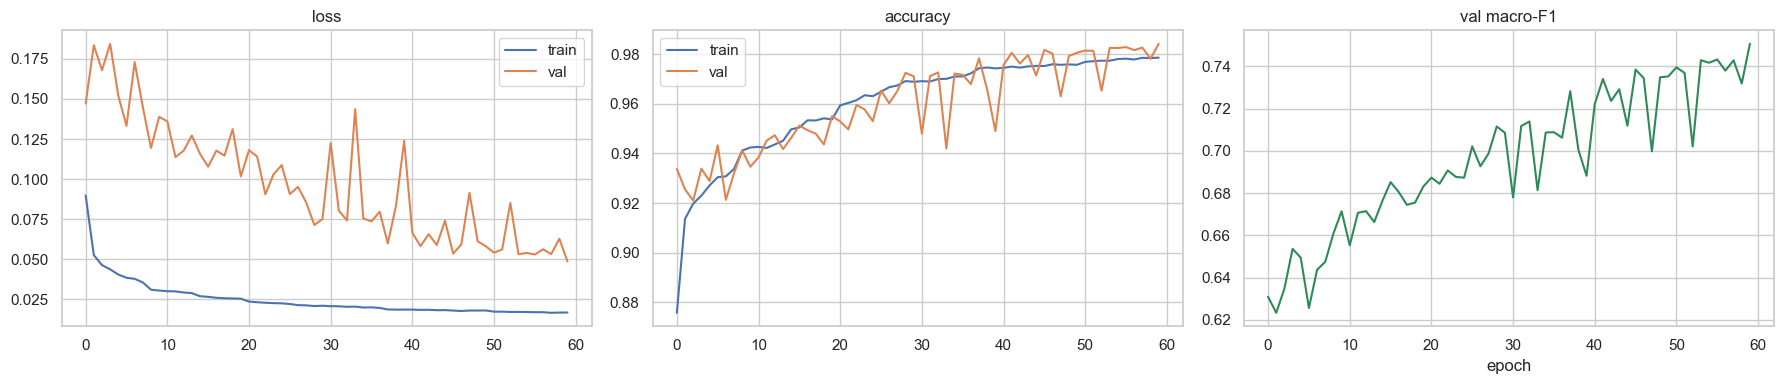

In [12]:
h = history.history
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="val")
axes[0].set_title("loss"); axes[0].legend()
axes[1].plot(h["accuracy"], label="train"); axes[1].plot(h["val_accuracy"], label="val")
axes[1].set_title("accuracy"); axes[1].legend()
axes[2].plot(f1_cb.history, color="seagreen")
axes[2].set_title("val macro-F1"); axes[2].set_xlabel("epoch")
plt.tight_layout(); plt.show()


## 9. Validation report (per-class & macro) — tuned model

In [13]:
y_pred = model.predict(X_val, batch_size=4096, verbose=0).argmax(axis=1)

all_labels = list(range(len(class_names)))   # tolerate classes absent from y_val/y_pred

print(f"Macro F1   : {f1_score(y_val, y_pred, labels=all_labels, average='macro',    zero_division=0):.4f}")
print(f"Weighted F1: {f1_score(y_val, y_pred, labels=all_labels, average='weighted', zero_division=0):.4f}\n")
print(classification_report(y_val, y_pred,
                            labels=all_labels,
                            target_names=class_names,
                            digits=4, zero_division=0))


Macro F1   : 0.7506
Weighted F1: 0.9864

                          precision    recall  f1-score   support

                  BENIGN     0.9999    0.9808    0.9903    340698
                     Bot     0.1941    0.9660    0.3233       294
                    DDoS     0.9945    0.9997    0.9971     19204
           DoS GoldenEye     0.9028    0.9987    0.9483      1544
                DoS Hulk     0.9282    0.9993    0.9624     34518
        DoS Slowhttptest     0.8586    0.9867    0.9182       825
           DoS slowloris     0.9600    0.9931    0.9763       870
             FTP-Patator     0.9346    0.9966    0.9646      1190
                PortScan     0.9921    0.9995    0.9958     23820
             SSH-Patator     0.4625    0.9966    0.6318       884
Web Attack - Brute Force     0.1663    0.9646    0.2837       226
        Web Attack - XSS     0.0370    0.0102    0.0160        98

                accuracy                         0.9841    424171
               macro avg     0.70

## 10. Confusion matrix (tuned model)


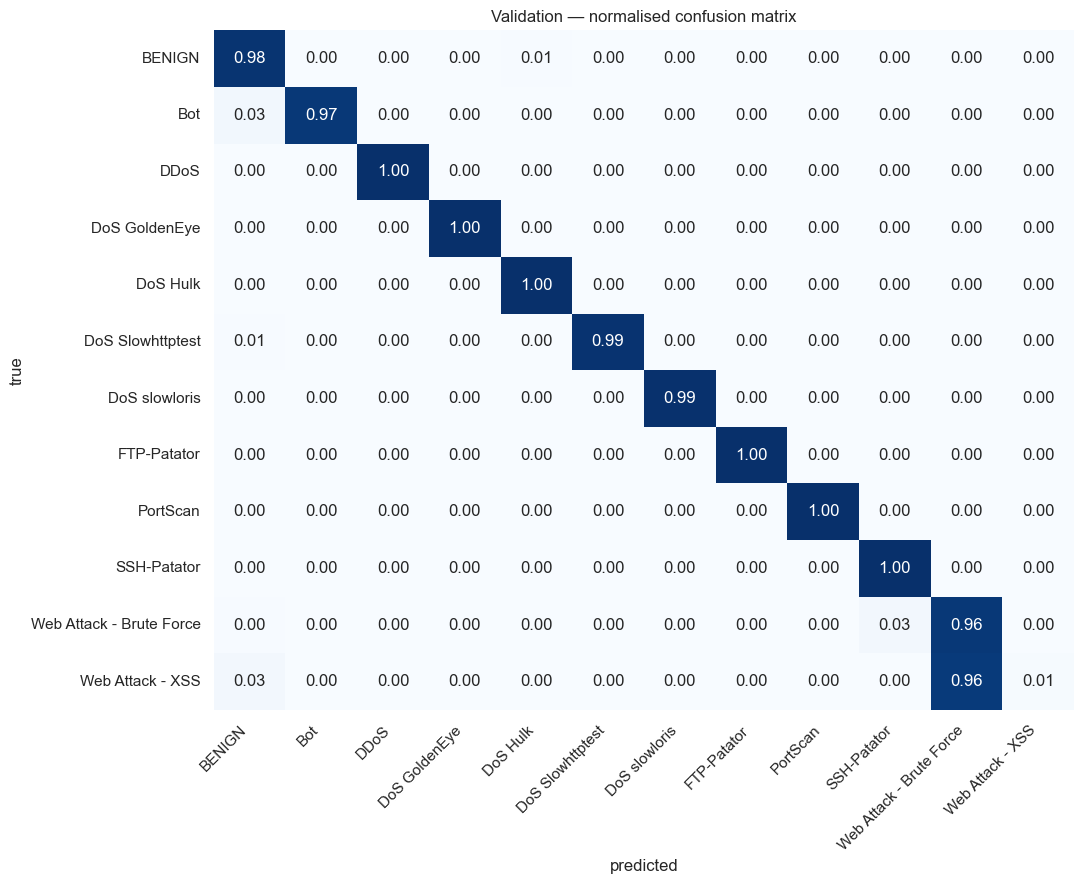

In [14]:
cm = confusion_matrix(y_val, y_pred, labels=all_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

plt.figure(figsize=(11, 9))
sns.heatmap(cm_norm, xticklabels=class_names, yticklabels=class_names,
            annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.xlabel("predicted"); plt.ylabel("true")
plt.title("Validation — normalised confusion matrix")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


## 11. Persist the best model and tuning history


In [15]:
# ModelCheckpoint already wrote the best epoch; re-save in canonical location
# (in case the in-memory `model` differs from the checkpoint).
model.save(cfg.MLP_MODEL_FILE)
print("Saved MLP ->", cfg.MLP_MODEL_FILE)


Saved MLP -> D:\smart_ids\smart_ids\models\mlp_model.keras


---
**Next:** `03_autoencoder_training.ipynb` for the unsupervised anomaly net.
